# Netflix Data anlysis using pandas 


## 1. Netflix focusing more on Movies or TV shows

In [ ]:
import pandas as pd
df=pd.read_csv("netflix_titles.csv")

In [96]:
df["cast"]=df['cast'].fillna("Unknown")
df["director"]=df["director"].fillna("Unknown")
df["country"]=df["country"].fillna("Unknown")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [10]:
df_mov_tv=df["type"].value_counts(normalize=True)*100
df_mov_tv.round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

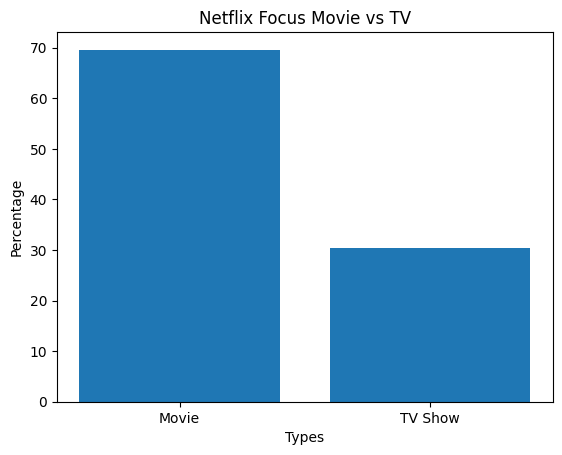

In [12]:
import matplotlib.pyplot as plt
plt.bar(df_mov_tv.index,df_mov_tv.values)
plt.title("Netflix Focus Movie vs TV")
plt.xlabel("Types")
plt.ylabel("Percentage");

## Bar chart illustrate Netflix focuses approximately 70% of its content on Movies,while TV Shows account around 30% of total library

## 2. Country Producing the most netflix content

In [15]:
df["country"].fillna("Unknown")

0       United States
1        South Africa
2             Unknown
3             Unknown
4               India
            ...      
8802    United States
8803          Unknown
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: object

In [5]:
df_explo=df.explode("country")
df_most_country=df_explo["country"].value_counts(normalize=True)*100
top5_percent=df_most_country.round(2).head()
top5_percent

country
United States     35.33
India             12.19
United Kingdom     5.25
Japan              3.07
South Korea        2.49
Name: proportion, dtype: float64

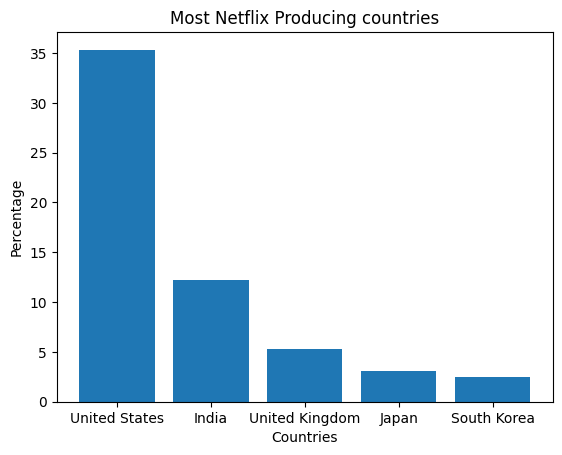

In [6]:
import matplotlib.pyplot as plt
plt.bar(top5_percent.index,top5_percent.values)
plt.title("Most Netflix Producing countries")
plt.xlabel("Countries")
plt.ylabel("Percentage");

## The Bar chart indicates that United States contributes approximately  35% of the total Netflix content, making it dominant content producing country

##  3. The year with highest content addition

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("netflix_titles.csv")

In [31]:
df["date_added"]=pd.to_datetime(df["date_added"], format='%B %d, %Y', errors='coerce')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  dtae_added    8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 894.6+ KB


In [33]:
df["year_added"]=df["date_added"].dt.year

In [34]:
df=df.dropna(subset=["year_added"])

In [35]:
df.loc[:, "year_added"]=df["year_added"].astype(int)

In [36]:
df_expl=df.explode('year_added')

In [37]:
df_year=df_expl["year_added"].value_counts(normalize=True)*100

In [38]:
df_year.round(2)

year_added
2019.0    22.95
2020.0    21.56
2018.0    18.66
2021.0    17.20
2017.0    13.37
2016.0     4.80
2015.0     0.84
2014.0     0.26
2011.0     0.15
2013.0     0.11
2012.0     0.03
2009.0     0.02
2008.0     0.02
2010.0     0.01
Name: proportion, dtype: float64

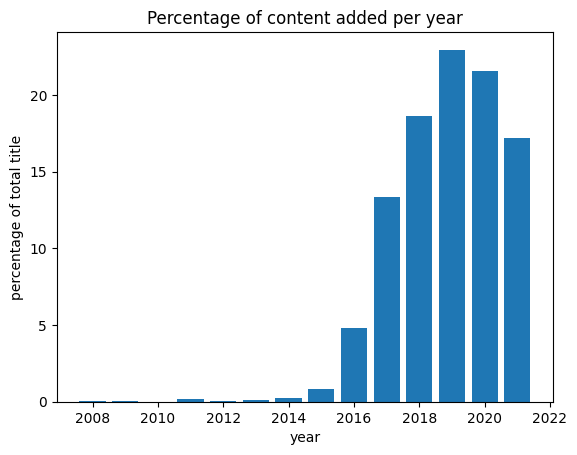

In [42]:
import matplotlib.pyplot as plt
plt.bar(df_year.index,df_year.values)
plt.xlabel("year")
plt.ylabel("percentage of total title")
plt.title("Percentage of content added per year");

## The Bar chart indicates that year in which the Netflix added the most content is 2019 with 23% titles added

##  4. Most common rating

In [56]:
rating_count=df["rating"].value_counts().head(10)
rating_count

rating
TV-MA    3183
TV-14    2133
TV-PG     838
R         799
PG-13     490
TV-Y7     330
TV-Y      300
PG        287
TV-G      212
NR         78
Name: count, dtype: int64

In [57]:
rating_count.idxmax()

'TV-MA'

In [58]:
rating_count.max()

np.int64(3183)

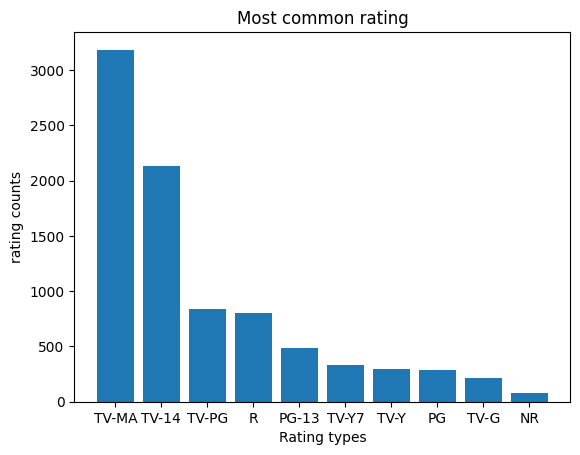

In [65]:
import matplotlib.pyplot as plt
plt.bar(rating_count.index,rating_count.values)
plt.xlabel("Rating types")
plt.ylabel("rating counts")
plt.title("Most common rating");

##  The Bar chart indicates that Netflix dataset shows that TV-MA is the most frequently assigned rating,indicating that  a sigmificant portion of content is targeted for mature audience

## 5. Most popular genres

In [60]:
df["genre_list"]=df['listed_in'].str.split(',')
df_exp=df.explode("genre_list")

In [68]:
df_popular_genre=df_exp['genre_list'].value_counts().head(5)

In [64]:
df_popular_genre

genre_list
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     761
 Independent Movies        736
 TV Dramas                 679
 Romantic Movies           613
Name: count, dtype: int64

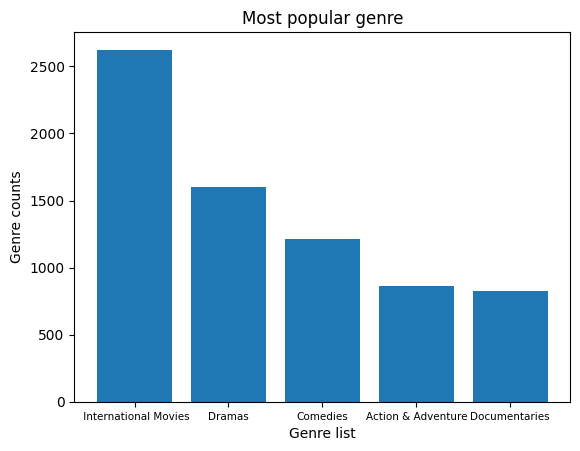

In [80]:
import matplotlib.pyplot as plt
plt.bar(df_popular_genre.index,df_popular_genre.values)
plt.xlabel("Genre list")
plt.xticks(fontsize=7.5)
plt.ylabel("Genre counts")
plt.title("Most popular genre");

## The Bar chart shows that most popular genres on Netflix is International Movies ,followed by Comedy and Dramas

# Conclusion
## 2019 had the highest content addition(35% of title)
## TV-MA is the most common rating among netflix titles
## US produces the majority of Netflix content
## Netflix focuses of its 70% of netflix content of movies and 30% of TV Shows

In [ ]:
df.to_csv("C:/Users/sumed/Downloads/archive (2)/netflix_cleaned.csv",index=True)